# Principle Component Analysis Statistical Arbitrage
This strategy attempts to decompose the returns of the whole market into key market and sector factors, and then trades the residual idiosyncratic returns, assuming that they are mean reverting. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from itertools import product

# Import data
df = pd.read_csv("prices.txt", delim_whitespace=True)

# Create final hold out for 150 days
hold_out = df.iloc[526:751]
df_prices = df.iloc[:525]

# Create returns data
returns = df_prices.pct_change()
returns = returns.dropna()


/var/folders/ny/pgx1yx0d5p5d6bxnkllv_jz40000gn/T/ipykernel_15457/1943959993.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("prices.txt", delim_whitespace=True)


In [22]:
# Create standard scaler object
scaler = StandardScaler()
scaler.set_output(transform="pandas")

# Standardise returns
sreturns = scaler.fit_transform(returns)
sreturns = sreturns.dropna()
sreturns.head()

,ALGO,AENO,LSST,SRNA,ELLT,AMRP,OTCS,HETT,HUXZ,DUCT,...,BLBT,BENI,ITPA,HTRK,NGTE,ILVX,FCSG,FARS,MHRM,EAFC
1,-1.491387,-1.632879,0.419701,-0.399980,-1.236207,-1.563865,-0.394909,-1.093867,-2.050334,-1.178335,...,0.841303,-0.297353,-1.433855,-0.475219,-2.501573,-2.093383,-1.447035,-1.685856,-0.545293,-0.712540
2,-0.647033,-0.074264,-0.928402,-0.114075,-1.036153,-0.983171,0.290559,-0.355502,0.782959,0.036288,...,0.833861,-0.021527,-0.697364,-0.426886,0.784357,-1.922267,-1.803382,-0.423528,-2.380848,1.063875
3,0.221904,-0.171508,1.633157,0.251995,1.784025,0.283973,-0.722979,-1.106247,0.397746,0.468431,...,-0.806119,-0.049285,-0.034387,-2.166444,1.032903,0.234404,-1.080699,-1.360750,0.230060,1.041281
4,1.165109,0.689436,1.407951,1.999191,0.070687,0.235564,0.396361,2.098826,0.725236,1.346549,...,1.488535,0.394619,0.071385,1.194730,1.732778,1.250323,1.720261,1.232686,-0.420009,-0.654230
5,-0.460136,-1.228433,-0.568227,-0.085368,-0.493439,-1.167463,-1.082058,-1.310171,0.047223,-0.896203,...,1.203864,-1.071606,-0.562379,0.312368,0.823641,-0.282311,-0.674846,-0.112995,-0.510085,0.882710


Next, an initial guess for the amount of components to include in the initial run of the strategy. Some key PCA component numbers to try include 1, 5, 10, 15, 20 and 30 through our walk-forward validation.

We don't require enough PCAs to explain 80% of the variance. Forcing PCA to explain 80% via 30 components mean using ~60% of assets as factors, which absorbs tradeable idiosyncratic risk into the factor model, and an overfitting risk too. 

As an aside, it makes sense that PC1 only explains ~20% of variance as ALGO shows high correlation with a basket of the other 50 securites. Idiosyncratic noise cancels out across 49 largely-independent names, so the average tracks the factor almost perfectly, even though no single instrument's own variance is factor-dominated (e.g. an instruments variance is dominated by ALGO).

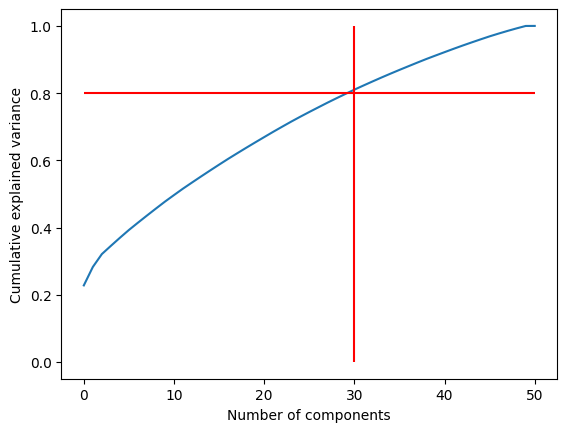

In [24]:
# Run PCA on the data to get an initial guess of an appropriate amount of components
pca_test_comps = PCA().fit(sreturns)

plt.plot(np.cumsum(pca_test_comps.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.hlines(y = 0.8, xmin = 0, xmax=50, colors='red')
plt.vlines(x = 30, ymin=0, ymax=1, colors='red')
plt.ylabel('Cumulative explained variance')
plt.show()


Now, building the actual strategy. Refer to pca_apporach.ipynb for some more in depth. Initially, we will use a 125 day window to train, and 50 days to test. 

In [ ]:
def pca_stat_arb(train_data, test_data, params):  
  n_components, s_threshold = params
  
  # Fit pca
  pca = PCA(n_components=n_components).fit(train_data)
  
  # Extract factor loadings (Eigenvectors): shape (n_components, n_assets):
  loadings = pca.components_ # loadings_{ij} of loadings_j shows how much each original variable is exposed to component i
  
  # Calculating factor returns from our returns - multiplying them by factor weights
  factor_returns = np.dot(test_data, loadings.T)
  
  # Reconstruct the expected test returns attributable to the factors: R_expected = F * W
  expected_returns = np.dot(factor_returns, loadings)

  # Calculate residual, idiosyncratic risk (residuals = actual - factor)
  residuals = test_data  - expected_returns
  
  # Next, need to model the mean-reversion of residuals, then extract standardised score and half-life. Need to fit factor loadings on rolling basis
  

In [ ]:
def walk_forward(none):
  none